In [7]:
from stopping_power_analysis import StoppingPowerAnalysis

import numpy as np
import matplotlib.pyplot as plt
from ase.visualize import view

In [8]:
# this one is old data with a (1,2,2) Al supercell
# data_directory = "/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/data/small_unitcell/"
# data_directory = "/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/data/small_every_timestep/"

# (2,2,2) supercell with the code that prevents charge transfer in the inital dft simulation
# data_directory = "/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/data/larger_unitcell/"

# (2,2,2) supercell WITHOUT the code that prevents charge transfer in the inital dft simulation
# data_directory = "/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/data/single_calculation/"


data_directory = "/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/data/322_supercell"


In [9]:
analysis = StoppingPowerAnalysis(data_directory)

/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/data/322_supercell/
{
    "40 keV": [
        "Al_stopping_40k_step1.gpw",
        "Al_stopping_40k_step2.gpw",
        "Al_stopping_40k_step3.gpw",
        "Al_stopping_40k_step4.gpw",
        "Al_stopping_40k_step5.gpw",
        "Al_stopping_40k_step6.gpw",
        "Al_stopping_40k_step7.gpw",
        "Al_stopping_40k_step8.gpw",
        "Al_stopping_40k_step9.gpw",
        "Al_stopping_40k_step10.gpw",
        "Al_stopping_40k_step11.gpw",
        "Al_stopping_40k_step12.gpw",
        "Al_stopping_40k_step13.gpw",
        "Al_stopping_40k_step14.gpw",
        "Al_stopping_40k_step15.gpw",
        "Al_stopping_40k_step16.gpw",
        "Al_stopping_40k_step17.gpw",
        "Al_stopping_40k_step18.gpw",
        "Al_stopping_40k_step19.gpw",
        "Al_stopping_40k_step20.gpw",
        "Al_stopping_40k_step21.gpw",
        "Al_stopping_40k_step22.gpw",
        "Al_stopping_40k_step23.gpw",
        "Al_stopping_40k_step24

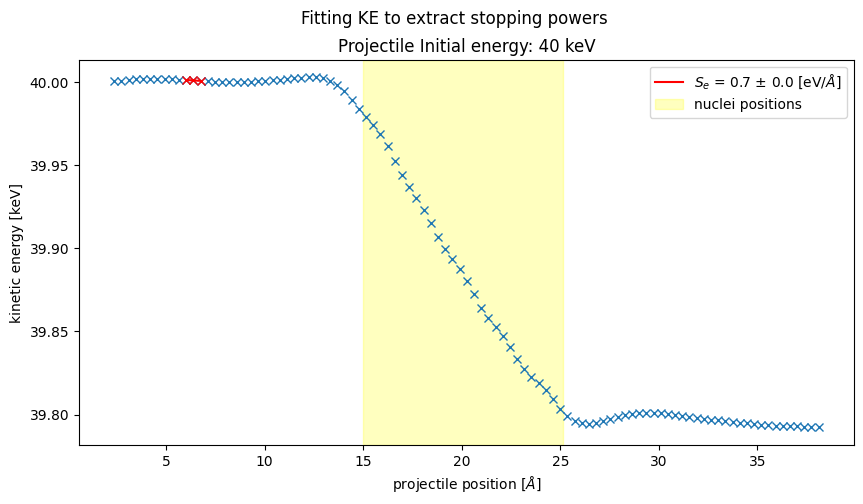

In [10]:
# window_size_params = [10,25]
# analysis.plot_kinetic_energies(window_size_params)
analysis.plot_kinetic_energies()

In [ ]:
# MONKEY PATCH THE FUNCTION TO ADD NEW FEATURES WITHOUT HAVING TO RELOAD THE DATA EVERY TIME
import utils

def new_plot_kinetic_energies(self):
    """
    plots projectile kinetic energy over the projectile trajectory
    performs a sliding window straight line fit (r^2 minimisation) to fit
    a straight line to the region where the projectile passes through the supercell
    extracts stopping power from this fit
    """

    n_subplots = len(self.kinetic_energies.keys())
    fig, axs = plt.subplots(n_subplots, figsize=(
        10, 5*n_subplots), sharex=True)
    # so that is works for the =1 case
    if n_subplots == 1:
        axs = [axs]

    fig.suptitle("Fitting KE to extract stopping powers")

    axs[-1].set_xlabel(r"projectile position [$\AA$]")
    _ = [ax.set_ylabel("kinetic energy [keV]") for ax in axs]

    for i in range(n_subplots):
        energy, kinetic_energies = list(self.kinetic_energies.items())[i]
        kinetic_energies = np.array(kinetic_energies) * 1e-3  # convert from eV to keV
        _, projectile_positions = list(self.projectile_positions.items())[i]

        ############################################
        # SHOWING ON THE PLOT WHERE THE LATTICE IS #
        ############################################

        # can get atom positions from any of the timesteps becuase lattice positions dont change
        # [0] -> first timestep, [:-1] -> exclude the projectile
        lattice_positions = self.atoms_dict[energy][0].get_positions()[:-1]
        lattice_start = min(lattice_positions[:, 0])
        lattice_end = max(lattice_positions[:, 0])
        axs[i].axvspan(lattice_start, lattice_end, color="yellow", alpha=0.25, label="nuclei positions")
        
        
        ###############################
        # PERFORM FIT ONLY IN LATTICE #
        ###############################

        timesteps_in_supercell = np.where((projectile_positions > lattice_start) & (projectile_positions < lattice_end))[0]
        print(timesteps_in_supercell)
        print(projectile_positions[timesteps_in_supercell[0] : timesteps_in_supercell[-1]])

        projectile_positions_supercell = projectile_positions[timesteps_in_supercell[0] : timesteps_in_supercell[-1]]
        kinetic_energies_supercell = kinetic_energies[timesteps_in_supercell[0] : timesteps_in_supercell[-1]]
        fit, cov = np.polyfit(projectile_positions_supercell, kinetic_energies_supercell, 1, cov=True)
        pfit = np.poly1d(fit)
        stopping_power = -fit[0]
        stopping_power_uncertainty = np.sqrt(cov[0][0])

        axs[i].set_title(f"Projectile Initial energy: {energy}")
        axs[i].plot(projectile_positions, kinetic_energies, "x")
        axs[i].plot(projectile_positions_supercell, kinetic_energies_supercell, 'x', color="red")
        axs[i].plot(projectile_positions_supercell, pfit(projectile_positions_supercell), color='red', label=rf"$S_e$ = {1e3*stopping_power:.1f} $\pm$ {1e3*stopping_power_uncertainty:.1f} [eV/$\AA$]")
        
        ####################################
        # # PERFORM SLIDING WINDOW FITTING #
        # #     and get stopping power
        # ##################################

        # # TODO: should be able to calculat the minimum window size from the size of the unit cell and from the distance travelled per timestep
        # fit, cov, x_window, y_window = utils.sliding_fit(
        #     projectile_positions, kinetic_energies, 3, 5)
        # stopping_power = -fit[0]
        # stopping_power_uncertainty = np.sqrt(cov[0][0])

        # axs[i].plot(x_window, y_window, "x", color="red")
        # axs[i].plot(x_window, np.poly1d(fit)(x_window), color="red",
        #             label=rf"$S_e$ = {1e3*stopping_power:.1f} $\pm$ {1e3*stopping_power_uncertainty:.1f} [eV/$\AA$]")


    _ = [ax.legend() for ax in axs]
    plt.show()




StoppingPowerAnalysis.plot_kinetic_energies = new_plot_kinetic_energies

[35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58
 59 60 61 62]
[np.float64(15.146545879197717), np.float64(15.511621025043908), np.float64(15.876674214814571), np.float64(16.241698670187418), np.float64(16.606686004815355), np.float64(16.97163303080558), np.float64(17.336543396361968), np.float64(17.701422386237873), np.float64(18.06627052907844), np.float64(18.431083801207677), np.float64(18.795858746607475), np.float64(19.160597250072634), np.float64(19.525306071242625), np.float64(19.889988901727254), np.float64(20.254642376817714), np.float64(20.619260641370566), np.float64(20.983841223132554), np.float64(21.348388373906232), np.float64(21.71290906554141), np.float64(22.077405872733674), np.float64(22.441875732396422), np.float64(22.806314298672437), np.float64(23.170722020312997), np.float64(23.535105213128997), np.float64(23.89946982933927), np.float64(24.263816082735975), np.float64(24.628139602451228)]


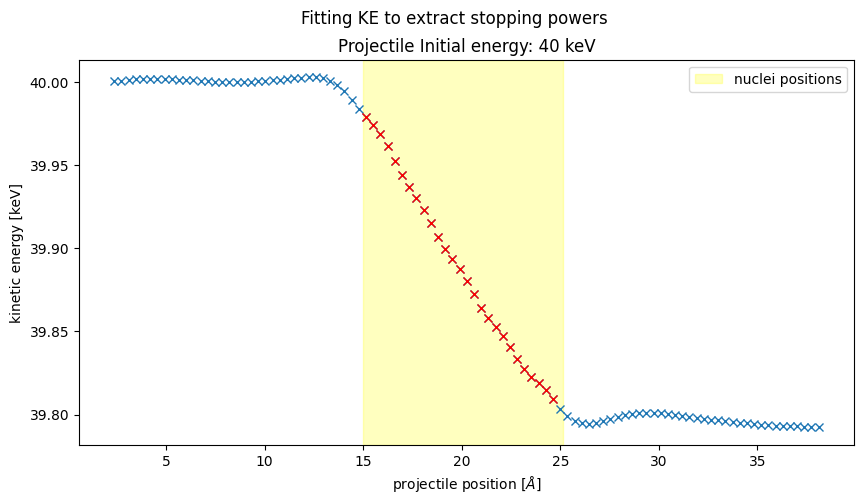

In [73]:
analysis.plot_kinetic_energies()


In [125]:
def new_extract_stopping_power(self):
    i = 0
    energy, kinetic_energies = list(self.kinetic_energies.items())[i]
    kinetic_energies = np.array(kinetic_energies) * 1e-3  # convert from eV to keV
    _, projectile_positions = list(self.projectile_positions.items())[i]

    # want to know in which region of the plots is the supercell
    lattice_positions = self.atoms_dict[energy][0].get_positions()[:-1]
    lattice_start = min(lattice_positions[:, 0])
    lattice_end = max(lattice_positions[:, 0])

    # get the data specifically for when the proton is inside the supercell
    timesteps_in_supercell = np.where((projectile_positions > lattice_start) & (projectile_positions < lattice_end))[0]
    projectile_positions_supercell = projectile_positions[timesteps_in_supercell[0] : timesteps_in_supercell[-1]]
    kinetic_energies_supercell = kinetic_energies[timesteps_in_supercell[0] : timesteps_in_supercell[-1]]


    fig,axs = plt.subplots(1,2, figsize=(15,5))
    fig.suptitle("Stopping Power Things")
    axs[0].set_ylabel("Kinetic Energy [keV]")
    axs[1].set_ylabel(r"$\frac{dKE}{dx}$ [keV/$\AA$]")
    _ = [ax.set_xlabel(r"Projectile Position [$\AA$]") for ax in axs.flatten()]
    _ = [ax.axvspan(lattice_start, lattice_end, color="yellow", alpha=0.25, label="nuclei positions") for ax in axs.flatten()]


    axs[0].plot(projectile_positions, kinetic_energies, "x")
    axs[0].plot(projectile_positions_supercell, kinetic_energies_supercell, "x", color="red")

    axs[1].plot(projectile_positions[:-1], np.diff(kinetic_energies))
    axs[1].plot(projectile_positions_supercell[:-1], np.diff(kinetic_energies_supercell), "x", color="red")
    


StoppingPowerAnalysis.extract_stopping_power = new_extract_stopping_power

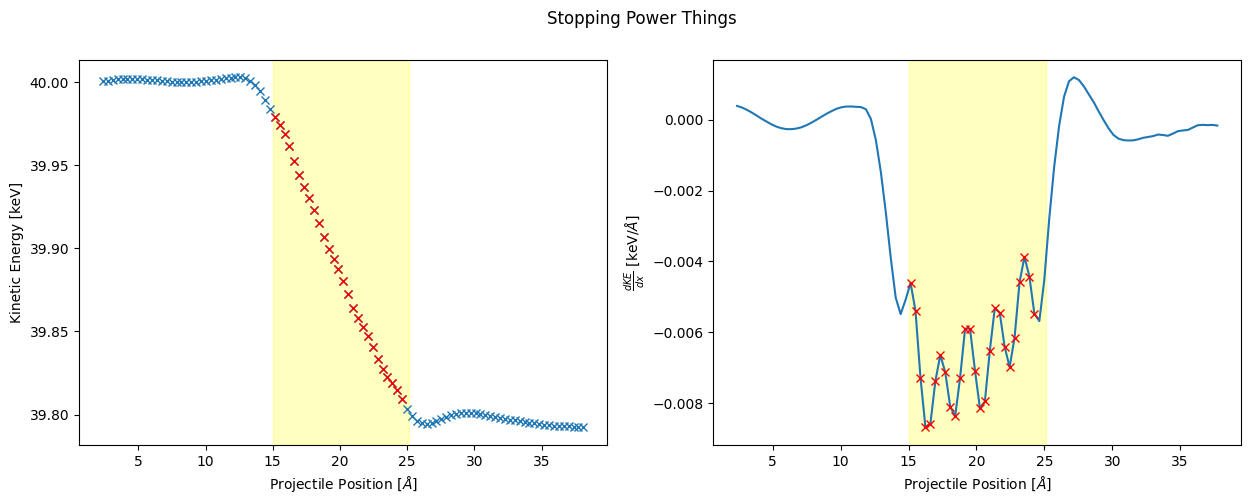

In [126]:
analysis.extract_stopping_power()